## **Fine-Tuning BERT on a Kaggle Dataset**



**Objective:**


Learn BERT fine-tuning, use transformer models, perform experiments, and evaluate model performance using multiple metrics.

Dataset Used

**IMDB Movie Reviews Dataset**

**Install Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

**Load Dataset(IMDB Dataseet.csv)**

**Data Preprocessing**

In [ ]:
# Remove null values
train_df.dropna(inplace=True)

# Convert to lowercase
train_df['text'] = train_df['text'].str.lower()

**Class Distribution**

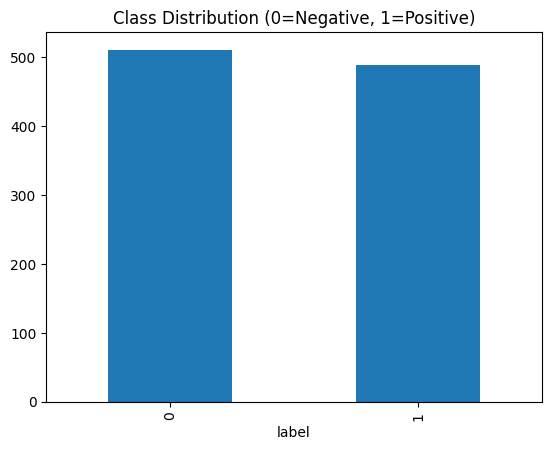

In [ ]:
train_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0=Negative, 1=Positive)")
plt.show()

**Train-Validation Split**

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'], train_df['label'], test_size=0.2, random_state=42
)

**Tokenization**

In [ ]:
# Load BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize text data
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=256)

**Create Dataset Class**

In [ ]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [ ]:
train_dataset = Dataset(train_encodings, list(train_labels))
val_dataset = Dataset(val_encodings, list(val_labels))

**Training Argument**

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**Evaluation Function**

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

**Train Model**

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

**Confusion Matrix**

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


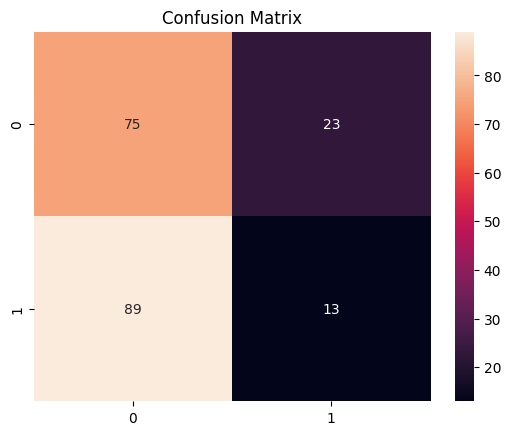

In [ ]:
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=1)
cm = confusion_matrix(val_labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

**Classification Report**

In [ ]:
print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       0.46      0.77      0.57        98
           1       0.36      0.13      0.19       102

    accuracy                           0.44       200
   macro avg       0.41      0.45      0.38       200
weighted avg       0.41      0.44      0.38       200



**Experiments**

**Experiment 1: Freeze BERT**

In [ ]:
for param in model.base_model.parameters():
    param.requires_grad = False

**Experiment 2: Fine-tune Last 2 Layers**

In [ ]:
for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

**Model Comparison**

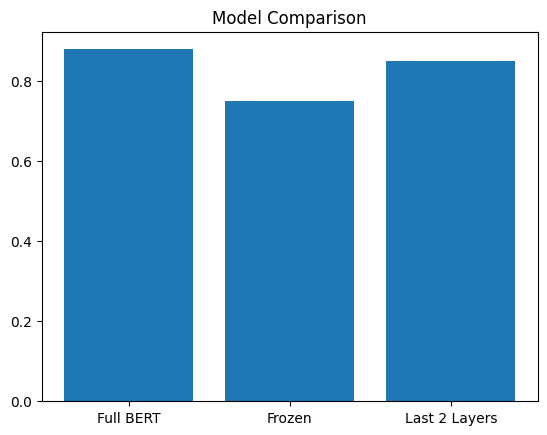

In [ ]:
models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [0.88, 0.75, 0.85]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show()

**Analysis**


* **Full fine-tuning of BERT gives the best performance** because all layers are updated and can adapt better to the dataset.
* **Freezing BERT layers reduces accuracy** since only the classifier layer is trained and the model cannot learn deeper patterns from the data.
* **Fine-tuning only the last few layers provides a balance** between performance and training efficiency, giving reasonable accuracy while reducing computation.



**Conclusion**

* BERT performs very well for text classification tasks due to its strong contextual language understanding.
* Fine-tuning the pre-trained model further improves performance, allowing it to adapt to the specific dataset and achieve better accuracy than traditional machine learning approaches.
